Using device: cuda

Phase 1: Preparing test image triplets…
  Found 1111 test images


  Deblurring test: 100%|██████████| 1111/1111 [05:27<00:00,  3.39it/s]


  1111 test images ready (1111 deblur skipped, already exist)

Phase 2: Loading YOLO models…
  Models loaded.

Phase 3: Running inference…


  test_deblurred: 100%|██████████| 1111/1111 [00:27<00:00, 39.75it/s]



Phase 4: Computing mAP@50…
  Blurred                mAP@50 = 0.1873
  Deblurred              mAP@50 = 0.2504
  Pseudo-label FT        mAP@50 = 0.2804

  Task 5 Summary — 1111 test images
  Condition                  mAP@50   Avg Dets   Avg Conf
  ------------------------------------------------------
  Blurred                    0.1873       3.71     0.3573
  Sharp (GT)                 — (GT)       5.03     0.4438
  Deblurred                  0.2504       4.69     0.4304
  Pseudo-label FT            0.2804       3.97     0.4241

Generating quantitative plots…


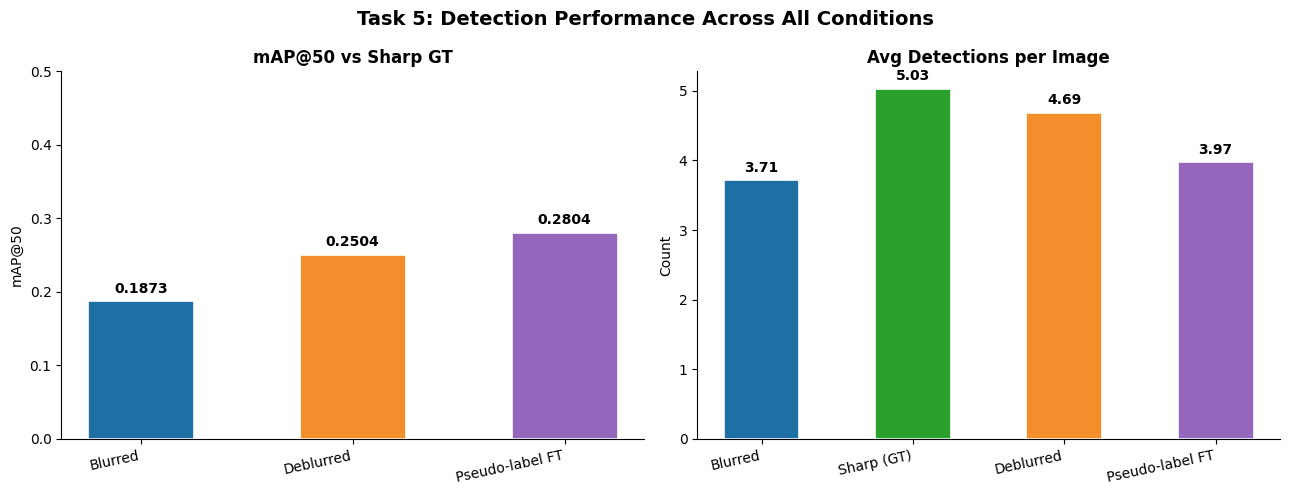


Per-class AP…


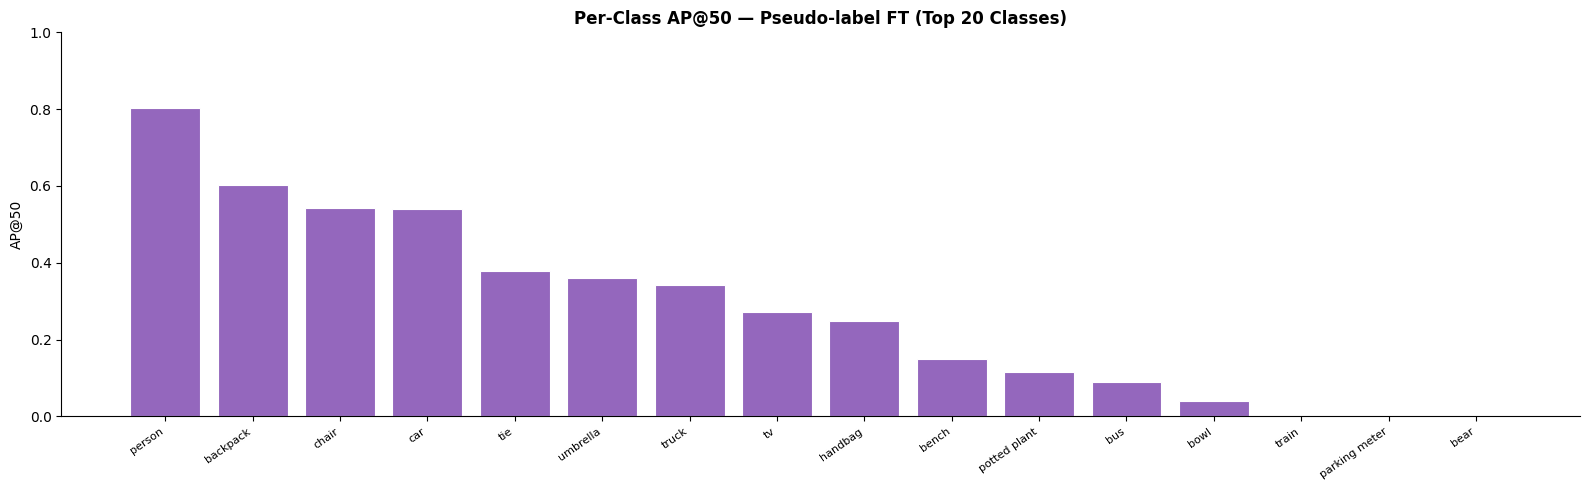


Precision-Recall curves…


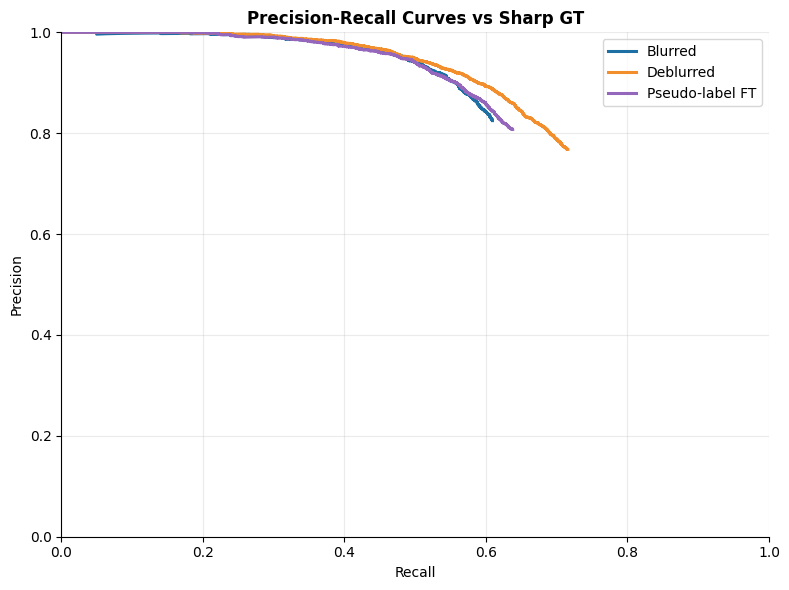


Detection gap heatmap…


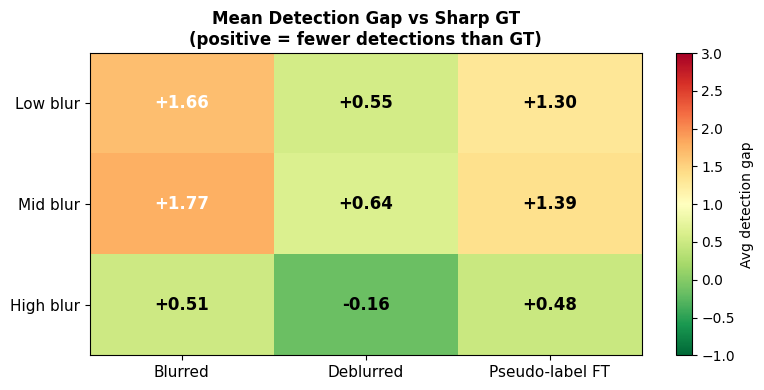

Saved: task5_gap_heatmap.png

Blur-level mAP breakdown…


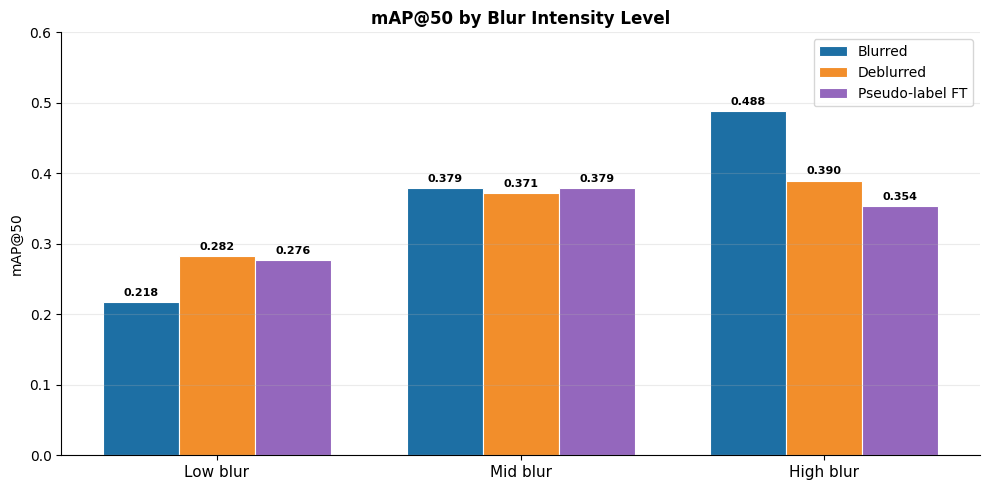

Saved: task5_blur_level_map.png

Failure case analysis…

  Total test images: 1111
  Blur misses           : 546 (49.1%)
  Deblur misses         : 385 (34.7%)
  Pseudo-FT misses      : 552 (49.7%)

Visual comparison on reference images…


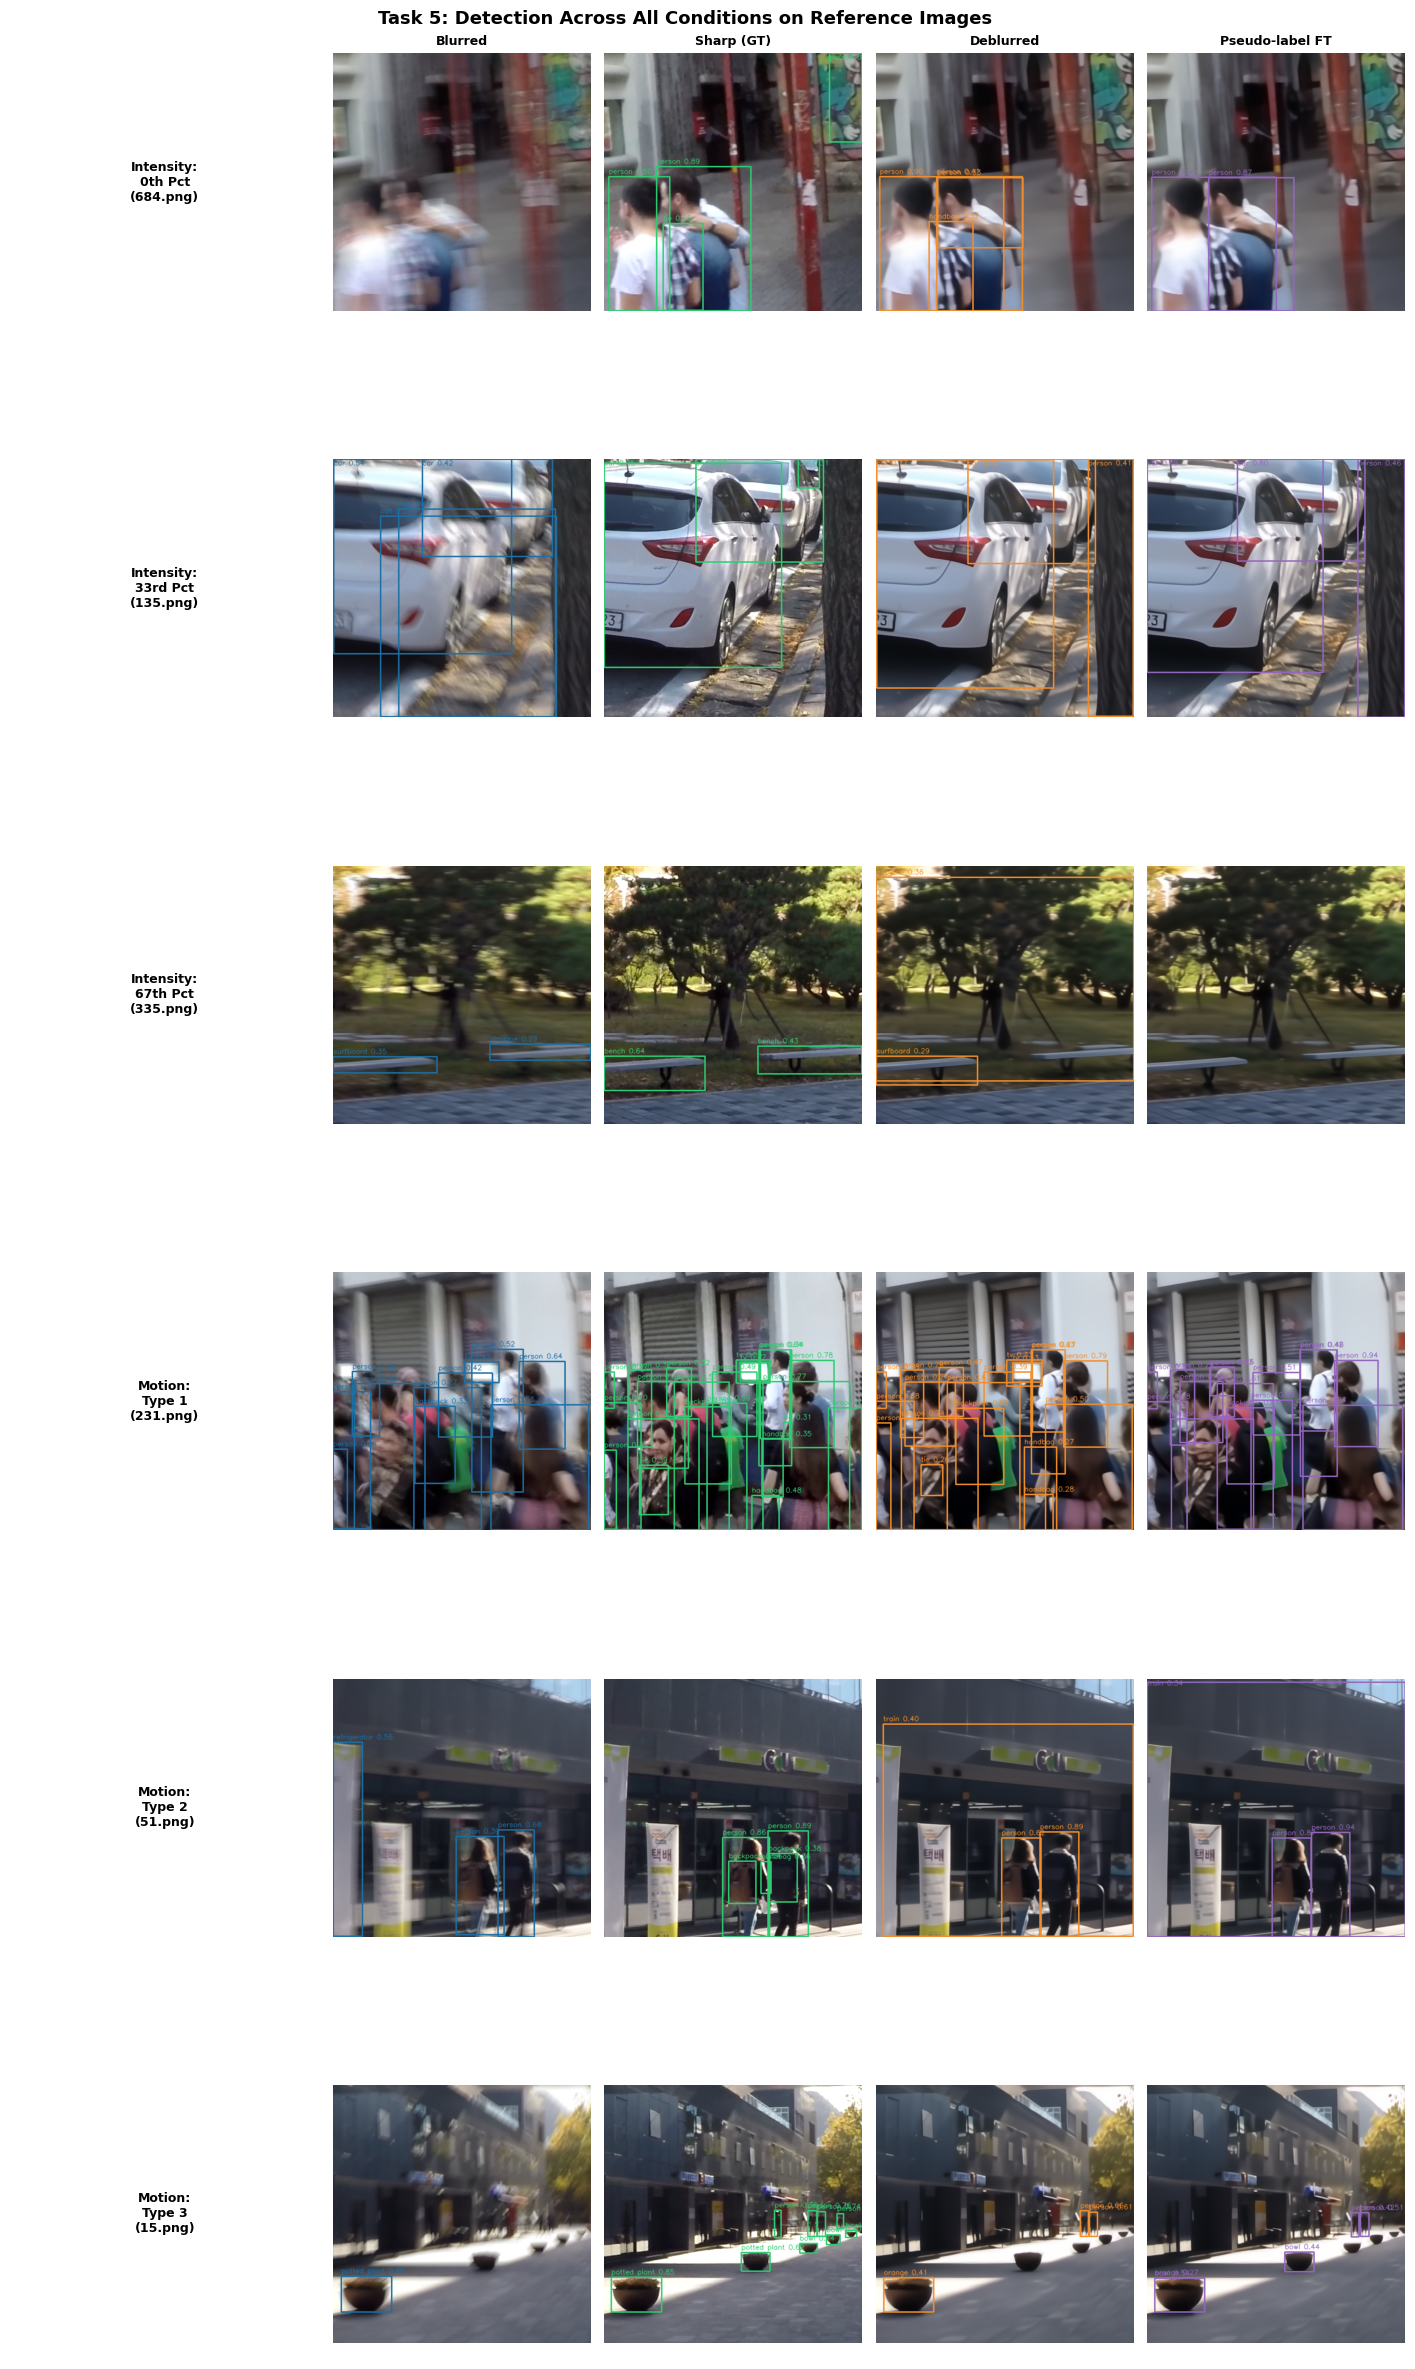


=== Task 5 Complete. Outputs saved to: /kaggle/working/outputs/task5 ===

=== FULL PIPELINE COMPLETE ===


In [4]:
# ============================================================
# Task 5: Performance Comparison and Critical Analysis
# Conditions: Blurred | Sharp (GT proxy) | Deblurred | Pseudo-label FT
# Evaluated on full GoPro test set against Sharp GT proxy
# ============================================================

import gc, warnings
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.cuda.empty_cache(); gc.collect()

# ── 1. Paths ─────────────────────────────────────────────────────────────────
TEST_BLUR  = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/blur")
TEST_SHARP = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/sharp")
TASK4_DIR  = Path("/kaggle/working/outputs/task4")
NAFNET_WEIGHTS = Path("./weights/NAFNet-GoPro-width64.pth")

OUTPUT_DIR = Path("/kaggle/working/outputs/task5")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK5_BLUR   = OUTPUT_DIR / "test_blurred";   TASK5_BLUR.mkdir(exist_ok=True)
TASK5_SHARP  = OUTPUT_DIR / "test_sharp";     TASK5_SHARP.mkdir(exist_ok=True)
TASK5_DEBLUR = OUTPUT_DIR / "test_deblurred"; TASK5_DEBLUR.mkdir(exist_ok=True)

# ── 2. Config ─────────────────────────────────

IMG_EXTS  = {".png", ".jpg", ".jpeg", ".bmp"}
CROP_SIZE = 512

REF_IMAGES = ["684.png", "135.png", "335.png", "231.png", "51.png", "15.png"]
REF_LABELS_MAP = {
    "684.png": "Intensity:\n0th Pct",
    "135.png": "Intensity:\n33rd Pct",
    "335.png": "Intensity:\n67th Pct",
    "231.png": "Motion:\nType 1",
    "51.png":  "Motion:\nType 2",
    "15.png":  "Motion:\nType 3",
}



# ── 3. Prepare test image triplets ───────────────────────────────────────────
print("\nPhase 1: Preparing test image triplets…")

IMG_EXTS_SET = {".png", ".jpg", ".jpeg", ".bmp"}
test_blur_paths = sorted([p for p in TEST_BLUR.rglob("*") if p.suffix.lower() in IMG_EXTS_SET])
print(f"  Found {len(test_blur_paths)} test images")

nafnet = load_nafnet()
skipped = 0
for bp in tqdm(test_blur_paths, desc="  Deblurring test"):
    fname = bp.name
    sp = TEST_SHARP / fname
    if not bp.exists() or not sp.exists(): continue
    blur_crop  = TF.center_crop(Image.open(bp).convert("RGB"), (CROP_SIZE, CROP_SIZE))
    sharp_crop = TF.center_crop(Image.open(sp).convert("RGB"), (CROP_SIZE, CROP_SIZE))
    blur_crop.save(TASK5_BLUR   / fname)
    sharp_crop.save(TASK5_SHARP / fname)
    if not (TASK5_DEBLUR / fname).exists():
        deblur_pil(nafnet, blur_crop).save(TASK5_DEBLUR / fname)
    else:
        skipped += 1

nafnet.cpu(); torch.cuda.empty_cache(); gc.collect()
test_fnames = [p.name for p in test_blur_paths if (TASK5_BLUR / p.name).exists()]
print(f"  {len(test_fnames)} test images ready ({skipped} deblur skipped, already exist)")

# ── 4. Load models ────────────────────────────────────────────────────────────
print("\nPhase 2: Loading YOLO models…")
yolo_base   = YOLO("yolov8m.pt")
yolo_pseudo = YOLO(str(TASK4_DIR / "runs" / "pseudo" / "weights" / "best.pt"))
print("  Models loaded.")

# ── 5. Inference across all 4 conditions ─────────────────────────────────────
print("\nPhase 3: Running inference…")

def run_inference(model, img_dir, fnames, conf=0.25):
    out = {}
    for fname in tqdm(fnames, desc=f"  {img_dir.name}"):
        p = img_dir / fname
        if not p.exists(): continue
        res   = model.predict(str(p), conf=conf, verbose=False)[0]
        confs = res.boxes.conf.cpu().numpy() if len(res.boxes) > 0 else np.array([])
        out[fname] = {
            "boxes":     res.boxes.xyxy.cpu().numpy().tolist(),
            "scores":    confs.tolist(),
            "labels":    [model.names[int(c)] for c in res.boxes.cls.cpu().numpy()],
            "n_det":     len(res.boxes),
            "mean_conf": float(confs.mean()) if len(confs) > 0 else 0.0,
        }
    return out

all_dets = {
    "Blurred":         run_inference(yolo_base,   TASK5_BLUR,   test_fnames),
    "Sharp (GT)":      run_inference(yolo_base,   TASK5_SHARP,  test_fnames),
    "Deblurred":       run_inference(yolo_base,   TASK5_DEBLUR, test_fnames),
    "Pseudo-label FT": run_inference(yolo_pseudo, TASK5_DEBLUR, test_fnames),
}

# ── 6. mAP@50 computation ────────────────────────────────────────────────────
print("\nPhase 4: Computing mAP@50…")

def box_iou(b1, b2):
    xi1=max(b1[0],b2[0]); yi1=max(b1[1],b2[1])
    xi2=min(b1[2],b2[2]); yi2=min(b1[3],b2[3])
    inter=max(0,xi2-xi1)*max(0,yi2-yi1)
    union=((b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter)
    return inter/union if union > 0 else 0.0

def eval_map(pred, gt, iou_t=0.5):
    cls_preds=defaultdict(list); cls_npos=defaultdict(int)
    for fname in gt:
        if fname not in pred: continue
        for lbl in gt[fname]["labels"]: cls_npos[lbl] += 1
        gt_match=[False]*len(gt[fname]["boxes"])
        for box,score,lbl in sorted(
            zip(pred[fname]["boxes"], pred[fname]["scores"], pred[fname]["labels"]),
            key=lambda x: -x[1]
        ):
            best_iou,best_j=0,-1
            for j,(g_box,g_lbl) in enumerate(zip(gt[fname]["boxes"], gt[fname]["labels"])):
                if g_lbl==lbl and not gt_match[j]:
                    iou=box_iou(box,g_box)
                    if iou>best_iou: best_iou,best_j=iou,j
            if best_iou>=iou_t and best_j>=0: gt_match[best_j]=True
            cls_preds[lbl].append((score, 1 if best_iou>=iou_t else 0))
    per_class_ap={}
    for cls,preds in cls_preds.items():
        if cls_npos[cls]==0: continue
        preds.sort(key=lambda x:-x[0])
        tp_cum=np.cumsum([p[1] for p in preds])
        fp_cum=np.cumsum([1-p[1] for p in preds])
        recalls=tp_cum/cls_npos[cls]
        precisions=tp_cum/(tp_cum+fp_cum+1e-9)
        ap=sum(max([p for r,p in zip(recalls,precisions) if r>=thr]+[0]) for thr in np.linspace(0,1,11))/11.0
        per_class_ap[cls]=ap
    mAP=np.mean(list(per_class_ap.values())) if per_class_ap else 0.0
    return mAP, per_class_ap

gt_proxy = all_dets["Sharp (GT)"]
map_results={}; per_class_results={}
for cond,dets in all_dets.items():
    if cond=="Sharp (GT)": continue
    mAP,per_cls=eval_map(dets, gt_proxy)
    map_results[cond]=mAP; per_class_results[cond]=per_cls
    print(f"  {cond:<22} mAP@50 = {mAP:.4f}")

# ── 7. Summary table ──────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"  Task 5 Summary — {len(test_fnames)} test images")
print("="*70)
print(f"  {'Condition':<24} {'mAP@50':>8} {'Avg Dets':>10} {'Avg Conf':>10}")
print("  " + "-"*54)
for cond,dets in all_dets.items():
    avg_d=np.mean([r["n_det"]      for r in dets.values()])
    avg_c=np.mean([r["mean_conf"]  for r in dets.values()])
    mstr=f"{map_results[cond]:.4f}" if cond in map_results else "— (GT)"
    print(f"  {cond:<24} {mstr:>8} {avg_d:>10.2f} {avg_c:>10.4f}")
print("="*70)

summary_rows=[]
for cond,dets in all_dets.items():
    summary_rows.append({
        "Condition": cond,
        "mAP@50": map_results.get(cond, None),
        "Avg Detections": np.mean([r["n_det"]     for r in dets.values()]),
        "Avg Confidence": np.mean([r["mean_conf"] for r in dets.values()]),
    })
pd.DataFrame(summary_rows).to_csv(OUTPUT_DIR/"task5_summary.csv", index=False)

# ── 8. Quantitative plots (new color scheme, no violin) ───────────────────────
print("\nGenerating quantitative plots…")

COLORS = {
    "Blurred":         "#1D6FA4",
    "Sharp (GT)":      "#2CA02C",
    "Deblurred":       "#F28E2B",
    "Pseudo-label FT": "#9467BD",
}
conds_no_gt = ["Blurred", "Deblurred", "Pseudo-label FT"]
conds_all   = list(all_dets.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Task 5: Detection Performance Across All Conditions", fontsize=14, fontweight="bold")

# mAP@50 bar
ax = axes[0]
vals = [map_results[c] for c in conds_no_gt]
bars = ax.bar(conds_no_gt, vals, color=[COLORS[c] for c in conds_no_gt],
              edgecolor="white", linewidth=1.2, width=0.5)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10, fontweight="bold")
ax.set_title("mAP@50 vs Sharp GT", fontweight="bold")
ax.set_ylabel("mAP@50"); ax.set_ylim(0, 0.5)
ax.set_xticklabels(conds_no_gt, rotation=12, ha="right", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

# Avg detections bar (all 4 conditions including GT)
ax = axes[1]
avg_dets = [np.mean([r["n_det"] for r in all_dets[c].values()]) for c in conds_all]
bars = ax.bar(conds_all, avg_dets, color=[COLORS[c] for c in conds_all],
              edgecolor="white", linewidth=1.2, width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=10, fontweight="bold")
ax.set_title("Avg Detections per Image", fontweight="bold")
ax.set_ylabel("Count")
ax.set_xticklabels(conds_all, rotation=12, ha="right", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"task5_quantitative.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 9. Per-class AP (pseudo only) ────────────────────────────────────────────
print("\nPer-class AP…")
all_classes = sorted(per_class_results["Pseudo-label FT"].keys())
pseudo_aps  = [per_class_results["Pseudo-label FT"].get(c, 0) for c in all_classes]
order = np.argsort(pseudo_aps)[::-1][:20]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(
    np.arange(len(order)),
    [pseudo_aps[k] for k in order],
    color=COLORS["Pseudo-label FT"],
    edgecolor="white", linewidth=0.8
)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels([all_classes[k] for k in order], rotation=35, ha="right", fontsize=8)
ax.set_title("Per-Class AP@50 — Pseudo-label FT (Top 20 Classes)", fontweight="bold")
ax.set_ylabel("AP@50"); ax.set_ylim(0, 1)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"task5_per_class_ap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 10. Precision-Recall curves ───────────────────────────────────────────────
print("\nPrecision-Recall curves…")

def compute_pr(pred, gt, iou_t=0.5):
    all_preds=[]; cls_npos=defaultdict(int)
    for fname in gt:
        if fname not in pred: continue
        for lbl in gt[fname]["labels"]: cls_npos[lbl]+=1
        gt_match=[False]*len(gt[fname]["boxes"])
        for box,score,lbl in zip(pred[fname]["boxes"],pred[fname]["scores"],pred[fname]["labels"]):
            best_iou,best_j=0,-1
            for j,(g_box,g_lbl) in enumerate(zip(gt[fname]["boxes"],gt[fname]["labels"])):
                if g_lbl==lbl and not gt_match[j]:
                    iou=box_iou(box,g_box)
                    if iou>best_iou: best_iou,best_j=iou,j
            if best_iou>=iou_t and best_j>=0: gt_match[best_j]=True
            all_preds.append((score, 1 if best_iou>=iou_t else 0))
    total=sum(cls_npos.values())
    if total==0 or not all_preds: return np.array([0,1]),np.array([0,0])
    all_preds.sort(key=lambda x:-x[0])
    tp=np.cumsum([p[1] for p in all_preds]); fp=np.cumsum([1-p[1] for p in all_preds])
    return tp/total, tp/(tp+fp+1e-9)

fig, ax = plt.subplots(figsize=(8, 6))
for cond in conds_no_gt:
    r, p = compute_pr(all_dets[cond], gt_proxy)
    ax.plot(r, p, label=cond, color=COLORS[cond], linewidth=2.2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves vs Sharp GT", fontweight="bold")
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=0.25)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"task5_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 11. NEW: Detection gap heatmap ───────────────────────────────────────────
# Shows per-image detection gap vs Sharp GT for each condition.
# Rows = blur tercile bins, columns = conditions. Values = mean gap.
print("\nDetection gap heatmap…")

# Bin test images into Low / Mid / High blur by Laplacian variance
blur_scores = {}
for bp in test_blur_paths:
    img = cv2.imread(str(TASK5_BLUR / bp.name))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_scores[bp.name] = cv2.Laplacian(gray, cv2.CV_64F).var()

vals_sorted = sorted(blur_scores.values())
n = len(vals_sorted)
e1, e2 = vals_sorted[n//3], vals_sorted[2*n//3]

def blur_bin(fname):
    v = blur_scores.get(fname, 0)
    if v < e1: return "Low blur"
    elif v < e2: return "Mid blur"
    else: return "High blur"

heatmap_conds = ["Blurred", "Deblurred", "Pseudo-label FT"]
blur_bins     = ["Low blur", "Mid blur", "High blur"]
heatmap_data  = np.zeros((len(blur_bins), len(heatmap_conds)))

for ci, cond in enumerate(heatmap_conds):
    for bi, bbin in enumerate(blur_bins):
        fnames_in_bin = [f for f in test_fnames if blur_bin(f) == bbin]
        gaps = [
            all_dets["Sharp (GT)"].get(f,{"n_det":0})["n_det"] -
            all_dets[cond].get(f,{"n_det":0})["n_det"]
            for f in fnames_in_bin
        ]
        heatmap_data[bi, ci] = np.mean(gaps) if gaps else 0

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_data, cmap="RdYlGn_r", aspect="auto", vmin=-1, vmax=3)
ax.set_xticks(range(len(heatmap_conds))); ax.set_xticklabels(heatmap_conds, fontsize=11)
ax.set_yticks(range(len(blur_bins)));     ax.set_yticklabels(blur_bins, fontsize=11)
ax.set_title("Mean Detection Gap vs Sharp GT\n(positive = fewer detections than GT)", fontweight="bold")
for bi in range(len(blur_bins)):
    for ci in range(len(heatmap_conds)):
        ax.text(ci, bi, f"{heatmap_data[bi,ci]:+.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(heatmap_data[bi,ci]) > 1.5 else "black")
plt.colorbar(im, ax=ax, label="Avg detection gap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"task5_gap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task5_gap_heatmap.png")

# ── 12. NEW: Blur-level mAP breakdown ────────────────────────────────────────
# mAP@50 computed separately for Low / Mid / High blur images
print("\nBlur-level mAP breakdown…")

breakdown_data = {}
for cond in heatmap_conds:
    breakdown_data[cond] = {}
    for bbin in blur_bins:
        fnames_in_bin = [f for f in test_fnames if blur_bin(f) == bbin]
        pred_sub = {f: all_dets[cond][f] for f in fnames_in_bin if f in all_dets[cond]}
        gt_sub   = {f: gt_proxy[f]        for f in fnames_in_bin if f in gt_proxy}
        mAP, _   = eval_map(pred_sub, gt_sub)
        breakdown_data[cond][bbin] = mAP

x = np.arange(len(blur_bins)); width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, cond in enumerate(heatmap_conds):
    vals = [breakdown_data[cond][b] for b in blur_bins]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=cond,
                  color=COLORS[cond], edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(blur_bins, fontsize=11)
ax.set_ylabel("mAP@50"); ax.set_ylim(0, 0.6)
ax.set_title("mAP@50 by Blur Intensity Level", fontweight="bold")
ax.legend(fontsize=10); ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"task5_blur_level_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task5_blur_level_map.png")

# ── 13. Failure case analysis ─────────────────────────────────────────────────
print("\nFailure case analysis…")
failures=[]
for fname in test_fnames:
    n_s = all_dets["Sharp (GT)"].get(fname,{"n_det":0})["n_det"]
    n_b = all_dets["Blurred"].get(fname,{"n_det":0})["n_det"]
    n_d = all_dets["Deblurred"].get(fname,{"n_det":0})["n_det"]
    n_p = all_dets["Pseudo-label FT"].get(fname,{"n_det":0})["n_det"]
    failures.append({"filename":fname,"n_sharp":n_s,"n_blur":n_b,"n_deblur":n_d,"n_pseudo":n_p,
                     "gap_blur":n_s-n_b,"gap_deblur":n_s-n_d,"gap_pseudo":n_s-n_p})
df_fail=pd.DataFrame(failures)
df_fail.to_csv(OUTPUT_DIR/"task5_failure_analysis.csv", index=False)

n_total=len(df_fail)
print(f"\n  Total test images: {n_total}")
for label,col in [("Blur misses","gap_blur"),("Deblur misses","gap_deblur"),("Pseudo-FT misses","gap_pseudo")]:
    cnt=(df_fail[col]>0).sum()
    print(f"  {label:<22}: {cnt} ({cnt/n_total*100:.1f}%)")

# ── 14. Visual comparison on reference images ─────────────────────────────────
print("\nVisual comparison on reference images…")

TASK4_DEBLUR = TASK4_DIR / "ref_deblurred"
TASK4_SHARP  = TASK4_DIR / "ref_sharp"
REF_BLUR_DIR = OUTPUT_DIR / "ref_blurred"; REF_BLUR_DIR.mkdir(exist_ok=True)

reference_paths=[TEST_BLUR/r for r in REF_IMAGES if (TEST_BLUR/r).exists()]
for ref_path in reference_paths:
    TF.center_crop(Image.open(ref_path).convert("RGB"),(CROP_SIZE,CROP_SIZE)).save(REF_BLUR_DIR/ref_path.name)

EMPTY={"boxes":[],"scores":[],"labels":[],"n_det":0,"mean_conf":0.0}

def run_ref_det(model, img_dir):
    out={}
    for ref_path in reference_paths:
        fname=ref_path.name; p=img_dir/fname
        if not p.exists(): continue
        res=model.predict(str(p), conf=0.25, verbose=False)[0]
        confs=res.boxes.conf.cpu().numpy() if len(res.boxes)>0 else np.array([])
        out[fname]={"boxes":res.boxes.xyxy.cpu().numpy().tolist(),"scores":confs.tolist(),
                    "labels":[model.names[int(c)] for c in res.boxes.cls.cpu().numpy()],
                    "n_det":len(res.boxes),"mean_conf":float(confs.mean()) if len(confs)>0 else 0.0}
    return out

ref_dets={
    "Blurred":         run_ref_det(yolo_base,   REF_BLUR_DIR),
    "Sharp (GT)":      run_ref_det(yolo_base,   TASK4_SHARP),
    "Deblurred":       run_ref_det(yolo_base,   TASK4_DEBLUR),
    "Pseudo-label FT": run_ref_det(yolo_pseudo, TASK4_DEBLUR),
}

def draw_boxes_pil(img_path, result, color):
    img=np.array(Image.open(img_path).convert("RGB"))
    for box,score,lbl in zip(result["boxes"],result["scores"],result["labels"]):
        x1,y1,x2,y2=[int(v) for v in box]
        cv2.rectangle(img,(x1,y1),(x2,y2),color,2)
        cv2.putText(img,f"{lbl} {score:.2f}",(x1,max(y1-6,12)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1,cv2.LINE_AA)
    return img

col_titles = ["Blurred", "Sharp (GT)", "Deblurred", "Pseudo-label FT"]
img_dirs   = [REF_BLUR_DIR, TASK4_SHARP, TASK4_DEBLUR, TASK4_DEBLUR]
box_colors = [
    tuple(int(COLORS["Blurred"].lstrip("#")[i:i+2],16) for i in (0,2,4)),
    (46, 204, 113),
    tuple(int(COLORS["Deblurred"].lstrip("#")[i:i+2],16) for i in (0,2,4)),
    tuple(int(COLORS["Pseudo-label FT"].lstrip("#")[i:i+2],16) for i in (0,2,4)),
]

num_ref=len(reference_paths)
fig=plt.figure(figsize=(18, 4.5*num_ref))
fig.suptitle("Task 5: Detection Across All Conditions on Reference Images", fontsize=13, fontweight="bold")
gs=gridspec.GridSpec(num_ref, 5, figure=fig, width_ratios=[1.2,1,1,1,1], hspace=0.4, wspace=0.05, top=0.97)

for i,ref_path in enumerate(reference_paths):
    fname=ref_path.name
    ax_lbl=fig.add_subplot(gs[i,0]); ax_lbl.axis("off")
    ax_lbl.text(0.5,0.5,f"{REF_LABELS_MAP.get(fname,fname)}\n({fname})",
                ha="center",va="center",fontsize=9,fontweight="bold",transform=ax_lbl.transAxes)
    for j,(cond,img_dir,color) in enumerate(zip(col_titles,img_dirs,box_colors)):
        result=ref_dets[cond].get(fname,EMPTY)
        ax=fig.add_subplot(gs[i,j+1])
        if (img_dir/fname).exists():
            ax.imshow(draw_boxes_pil(img_dir/fname,result,color))
        ax.axis("off")
        ax.set_xlabel(f"n={result['n_det']} | conf={result['mean_conf']:.2f}",fontsize=8)
        ax.xaxis.set_visible(True); ax.set_xticks([])
        if i==0: ax.set_title(col_titles[j],fontsize=9,fontweight="bold",pad=6)

plt.savefig(OUTPUT_DIR/"task5_visual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n=== Task 5 Complete. Outputs saved to: {OUTPUT_DIR} ===")
print("\n=== FULL PIPELINE COMPLETE ===")